# Phase 0 — Setup and data exploration

Goal: every dataset downloaded, loaded and understood. **Done when:** BigBasket, Flipkart and Abt-Buy are profiled side by side.

All logic lives in `src/data_io.py` and `src/eda.py`; this notebook only displays results.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
from src import data_io
from src.eda import profile_table, null_percent, top_values, unit_mentions

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 200)
FIG = ROOT / 'reports' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

## 1. Load every dataset

In [2]:
bb = data_io.load_bigbasket()
fk = data_io.load_flipkart()
ab = data_io.load_abt_buy()
ag = data_io.load_amazon_google()
off = data_io.load_off_india()
wdc_pair = data_io.load_wdc_products('pair', 80, 'gs')
wdc_pair_train = data_io.load_wdc_products('pair', 80, 'train', 'large')
wdc_multi = data_io.load_wdc_products('multi', 80, 'gs')
pave = pd.concat([data_io.load_wdc_pave(split='train'), data_io.load_wdc_pave(split='test')])
akshar = data_io.load_aksharantar_hindi('train')
tax = data_io.load_google_taxonomy()

inventory = pd.DataFrame([
    ('BigBasket', len(bb), bb.shape[1]),
    ('Flipkart', len(fk), fk.shape[1]),
    ('Abt', len(ab['left']), ab['left'].shape[1]),
    ('Buy', len(ab['right']), ab['right'].shape[1]),
    ('Abt-Buy matches', len(ab['matches']), 2),
    ('Amazon', len(ag['left']), ag['left'].shape[1]),
    ('Google', len(ag['right']), ag['right'].shape[1]),
    ('Amazon-Google matches', len(ag['matches']), 2),
    ('WDC Products 80% pairs (test)', len(wdc_pair), wdc_pair.shape[1]),
    ('WDC Products 80% pairs (train large)', len(wdc_pair_train), wdc_pair_train.shape[1]),
    ('WDC Products 80% multi-class (test)', len(wdc_multi), wdc_multi.shape[1]),
    ('WDC-PAVE offers (train+test)', len(pave), pave.shape[1]),
    ('Open Food Facts India', len(off), off.shape[1]),
    ('Aksharantar Hindi (train)', len(akshar), akshar.shape[1]),
    ('Google Product Taxonomy paths', len(tax), tax.shape[1]),
], columns=['dataset', 'rows', 'columns'])
inventory

,dataset,rows,columns
0,BigBasket,27555,9
1,Flipkart,20000,15
2,Abt,1081,4
3,Buy,1092,5
4,Abt-Buy matches,1097,2
5,Amazon,1363,5
6,Google,3226,5
7,Amazon-Google matches,1300,2
8,WDC Products 80% pairs (test),4500,17
9,WDC Products 80% pairs (train large),19835,17


## 2. Side-by-side profile: BigBasket, Flipkart, Abt-Buy (the Phase 0 deliverable)

In [3]:
profiles = pd.DataFrame([
    profile_table(bb, 'BigBasket', 'product', 'brand'),
    profile_table(fk, 'Flipkart', 'product_name', 'brand'),
    profile_table(ab['left'], 'Abt', 'name'),
    profile_table(ab['right'], 'Buy', 'name', 'manufacturer'),
    profile_table(ag['left'], 'Amazon', 'title', 'manufacturer'),
    profile_table(ag['right'], 'Google', 'name', 'manufacturer'),
    profile_table(off, 'OFF India', 'product_name', 'brands'),
]).set_index('dataset').T
profiles.to_csv(ROOT / 'reports' / 'phase0_profile.csv')
profiles

dataset,BigBasket,Flipkart,Abt,Buy,Amazon,Google,OFF India
rows,27555,20000,1081,1092,1363,3226,21189
columns,9,15,4,5,5,5,6
name column,product,product_name,name,name,title,name,product_name
mean null % (all cols),3.5,2.0,15.3,17.4,1.7,19.7,27.8
null % in name,0.0,0.0,0.0,0.0,0.0,0.0,16.32
exact duplicate rows,354,0,0,0,0,0,0
duplicate names,4014,7324,0,13,18,205,2376
duplicate names (lowercased),4043,7377,0,13,18,205,3372
name length chars (median),30,39,55,48,33,55,17
name length tokens (mean),5.7,6.4,9.1,8.3,5.7,9.3,3.0


## 3. Different schemas for the same kind of data (motivates Phase 1, R1)

In [4]:
for name, df in [('BigBasket', bb), ('Flipkart', fk), ('Abt', ab['left']), ('Buy', ab['right']), ('Amazon', ag['left']), ('OFF India', off)]:
    print(f'{name:10s}', list(df.columns))

BigBasket  ['product', 'category', 'sub_category', 'brand', 'sale_price', 'market_price', 'type', 'rating', 'description']
Flipkart   ['uniq_id', 'crawl_timestamp', 'product_url', 'product_name', 'product_category_tree', 'pid', 'retail_price', 'discounted_price', 'image', 'is_FK_Advantage_product', 'description', 'product_rating', 'overall_rating', 'brand', 'product_specifications']
Abt        ['id', 'name', 'description', 'price']
Buy        ['id', 'name', 'description', 'manufacturer', 'price']
Amazon     ['id', 'title', 'description', 'manufacturer', 'price']
OFF India  ['code', 'product_name', 'brands', 'categories', 'quantity', 'countries_tags']


In [5]:
pd.concat({'BigBasket': null_percent(bb), 'Flipkart': null_percent(fk), 'Abt': null_percent(ab['left']), 'Buy': null_percent(ab['right'])}, axis=1)

,BigBasket,Flipkart,Abt,Buy
rating,31.3,NaN,NaN,NaN
description,0.4,0.0,0.0,40.4
product,0.0,NaN,NaN,NaN
category,0.0,NaN,NaN,NaN
sub_category,0.0,NaN,NaN,NaN
sale_price,0.0,NaN,NaN,NaN
brand,0.0,29.3,NaN,NaN
type,0.0,NaN,NaN,NaN
market_price,0.0,NaN,NaN,NaN
discounted_price,NaN,0.4,NaN,NaN


## 4. Sample names

In [6]:
pd.DataFrame({
    'BigBasket': bb['product'].sample(8, random_state=42).values,
    'Flipkart': fk['product_name'].sample(8, random_state=42).values,
    'Abt': ab['left']['name'].sample(8, random_state=42).values,
    'Buy': ab['right']['name'].sample(8, random_state=42).values,
})

,BigBasket,Flipkart,Abt,Buy
0,"Knutzella Bar Bites - Mini, Gluten-free, Vegan",Avaron Projekt Moustache Brooch,Pioneer Sirius Bus Interface - CDSB10,SIRIUS SCVDOC1 SiriusConnect? Universal Vehicle Kit
1,Standard Large - 34 Diaper Pants,Grafion by Grafion - Comfort Feel Women's Tube Bra,Panasonic Black 8.5' Portable DVD Player - DVDLS86,Panasonic KX-TG4500B Corded/Cordless Telephone
2,Color Protection & Radiance Conditioner - For Color-Treated Hair,Blessed Ring Plant Container Set,LG 24' LDS4821BB Semi Integrated Built In Black Dishwasher - LDS4821BK,Canon Black Ink Cartridge - 0615B002
3,"Stainless Steel Lunch Box/Tiffin Set - Olive Green, BB 577 3",JRB 1042 Smallest Mobile Powered By OTG Enabled Android Smart Phone Portable...,Belkin Cush Top For Computer Laptop - F8N044SLV,Sony Cyber-shot DSC-W150 Digital Camera - Silver - DSCW150
4,Muniheal Oil,Northern Lights Striped Men's Polo Neck T-Shirt,Sony Black HD Radio With Dock For iPod And iPhone - XDRS10HDIP,Onkyo TXSR506 A/V Receiver
5,Roasted Peanuts - Lemon & Chilli,Nirosha Alloy Bangle Set,LaCie 1TB USB 2.0 External Hard Drive - 301304U,Canon SELPHY CP760 Dye Sublimation Printer - 2565B001
6,Xpress Handy Juicer 2-In-1 - Multicolour,Pearstone NP-95 Camera Battery Charger,Toshiba 22' Black LCD HDTV - 22AV500U,Sony Playstation 3 Blu-Ray DVD Remote - 98046
7,Vitamin E Face Pack,JDK NOVELTY Hand-held Bag,Canon Black EF 70-300mm F/4-5.6 IS USM Telephoto Zoom Lens - 0345B002,Klipsch Groove PM20 Computer Speakers - 1007596


## 5. Name length distribution

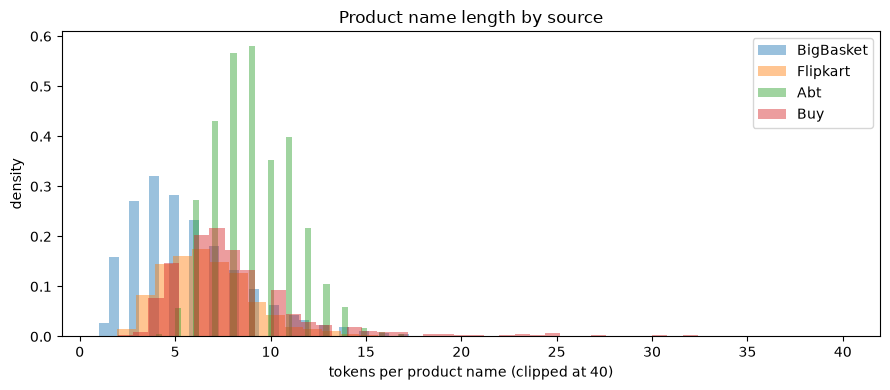

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
for name, s in [('BigBasket', bb['product']), ('Flipkart', fk['product_name']), ('Abt', ab['left']['name']), ('Buy', ab['right']['name'])]:
    s.dropna().astype(str).str.split().str.len().clip(upper=40).plot.hist(bins=40, alpha=0.45, density=True, ax=ax, label=name)
ax.set_xlabel('tokens per product name (clipped at 40)')
ax.set_ylabel('density')
ax.legend()
ax.set_title('Product name length by source')
fig.tight_layout()
fig.savefig(FIG / 'phase0_name_length.png', dpi=120)

## 6. Unit spellings (motivates Phase 2 quantity normalisation)

In [8]:
units = pd.DataFrame({
    'BigBasket': pd.Series(unit_mentions(bb['product'])),
    'Flipkart': pd.Series(unit_mentions(fk['product_name'])),
    'Abt': pd.Series(unit_mentions(ab['left']['name'])),
    'Buy': pd.Series(unit_mentions(ab['right']['name'])),
}).fillna(0).astype(int)
units.sort_values('BigBasket', ascending=False).head(25)

,BigBasket,Flipkart,Abt,Buy
g,582,64,21,27
ml,387,77,0,0
kg,233,4,0,0
cm,137,563,1,0
gm,112,9,0,0
l,99,219,1,2
pcs,81,19,0,0
mm,74,36,16,19
inch,64,146,0,6
mg,58,0,0,0


## 7. Top brands and categories

In [9]:
pd.concat({'BigBasket brand': top_values(bb['brand']), 'Flipkart brand': top_values(fk['brand']), 'Buy manufacturer': top_values(ab['right']['manufacturer'])}, axis=1)

BigBasket brand       Flipkart brand       Buy manufacturer      
               value count          value count            value count
0             Fresho   638    Allure Auto   469             Sony   170
1           bb Royal   539        Regular   313        Panasonic    99
2            BB Home   428         Voylla   299            Canon    86
3                 DP   250           Slim   288   LG Electronics    63
4   Fresho Signature   171   TheLostPuppy   229          Samsung    57
5           bb Combo   168     Karatcraft   211            Apple    28
6               Amul   153          Black   167           Garmin    27
7             INATUR   146          White   155            Sanus    24
8           Himalaya   141   DailyObjects   144            Nikon    24
9              Dabur   138       Speedwav   141          Toshiba    24
10          GoodDiet   134    Radiant Bay   132         Logitech    22
11             Cello   124            Red   103   Speck Products    20
12              Nike   124       Enthopia   101          LINKSYS    19
13              Iveo   118           Pink   100            Denon    19
14          BIOTIQUE   117      BlueStone    99            Weber    17

In [10]:
print('BigBasket categories:', bb['category'].nunique(), '| sub_categories:', bb['sub_category'].nunique())
display(top_values(bb['category'], 20))
print('Flipkart category-tree roots:')
fk_root = fk['product_category_tree'].str.strip('[]"').str.split('>>').str[0].str.strip()
display(top_values(fk_root, 15))

BigBasket categories: 11 | sub_categories: 90


,value,count
0,Beauty & Hygiene,7867
1,Gourmet & World Food,4690
2,"Kitchen, Garden & Pets",3580
3,Snacks & Branded Foods,2814
4,"Foodgrains, Oil & Masala",2676
5,Cleaning & Household,2675
6,Beverages,885
7,"Bakery, Cakes & Dairy",851
8,Baby Care,610
9,Fruits & Vegetables,557


Flipkart category-tree roots:


,value,count
0,Clothing,6198
1,Jewellery,3531
2,Footwear,1227
3,Mobiles & Accessories,1099
4,Automotive,1012
5,Home Decor & Festive Needs,929
6,Beauty and Personal Care,710
7,Home Furnishing,700
8,Kitchen & Dining,647
9,Computers,578


## 8. Duplicates inside BigBasket (how much entity resolution is there to do?)

In [11]:
low = bb['product'].str.lower().str.strip()
dup_groups = bb[low.duplicated(keep=False)].assign(name_lower=low).sort_values('name_lower')
print('rows whose lower-cased name appears more than once:', len(dup_groups), '| distinct such names:', dup_groups['name_lower'].nunique())
dup_groups[['product', 'brand', 'category', 'sale_price']].head(12)

rows whose lower-cased name appears more than once: 7034 | distinct such names: 2991


,product,brand,category,sale_price
20241,1-2-3 Noodles - Chicken Flavour,Wai Wai,Snacks & Branded Foods,12.00
21400,1-2-3 Noodles - Chicken Flavour,Wai Wai,Snacks & Branded Foods,12.00
17372,1-2-3 Noodles - Pure Vegetarian,Wai Wai,Snacks & Branded Foods,28.00
25403,1-2-3 Noodles - Pure Vegetarian,Wai Wai,Snacks & Branded Foods,28.00
9485,1-2-3 Noodles - Veg Masala Flavour,Wai Wai,Snacks & Branded Foods,12.00
19530,1-2-3 Noodles - Veg Masala Flavour,Wai Wai,Snacks & Branded Foods,12.00
813,100% Green Tea,Sprig Tea,Beverages,141.55
20678,100% Green Tea,Sprig Tea,Beverages,62.10
24328,100% Melamine 3D Serving Spoon - Orange,Iveo,"Kitchen, Garden & Pets",179.00
26339,100% Melamine 3D Serving Spoon - Orange,Iveo,"Kitchen, Garden & Pets",179.00


## 9. Benchmarks: WDC Products and the matching task

In [12]:
print('WDC 80% pair test label balance:', wdc_pair['label'].value_counts().to_dict())
print('WDC 80% pair train(large) label balance:', wdc_pair_train['label'].value_counts().to_dict())
print('WDC 80% multi-class test: offers', len(wdc_multi), '| products (labels)', wdc_multi['label'].nunique())
wdc_pair[['title_left', 'title_right', 'label']].sample(6, random_state=42)

WDC 80% pair test label balance: {0: 4000, 1: 500}
WDC 80% pair train(large) label balance: {0: 11364, 1: 8471}
WDC 80% multi-class test: offers 1000 | products (labels) 500


,title_left,title_right,label
2323,LaCie Rugged Thunderbolt USB-C 4TB,LaCie 2TB Rugged Thunderbolt USB-C + USB 3.0,0
3686,LOGITECH - HD WEBCAM C270 PACKAGING REFRESHIN CAM,C922 Logitech Pro Stream Full HD Webcam,0
2974,"Elixir Nanoweb Coated Acoustic Guitar String Set, Phosphor Bronze, .010-.047",Elixir 16052 Nanoweb Acoustic Guitar Strings Set - Light .012 -.053,0
2992,"3M - Privacy Filter19\"" LCD/Notebook",3M - PF19.0 PRIVACY FILTER BLACK F-FEEDS,1
468,"Corsair Vengeance LPX 16GB, DDR4, 2400MHz (PC4-19200), CL16, 1.2V, XMP 2.0,D...",Corsair Vengeance LPX 8GB 288-Pin DDR4 SDRAM DDR4 3000 (PC4 24000) Desktop M...,0
2640,Zebra Zxp1 Black Ribbon (1000 Images),Evolis Zenius & Primacy Black Printer Ribbon RCT023NAA,0


## 10. WDC-PAVE: which attributes exist? (check before planning Phase 3 evaluation)

In [13]:
pave_pairs = data_io.pave_attribute_pairs(pave)
print('offers by category:'); display(pave['category'].value_counts())
print('attribute-value pairs:', len(pave_pairs))
pave_pairs['attribute'].value_counts().head(30)

offers by category:

category
Computers And Accessories    174
Home And Garden              142
Office Products              118
Jewelry                       99
Grocery And Gourmet Food      32
Name: count, dtype: int64

attribute-value pairs: 2728


attribute
Product Type                 591
Manufacturer Stock Number    247
Manufacturer                 227
Part Number                  177
Width                        168
Brand                        135
Color(s)                     117
Height                       115
Interface                    108
Pack Quantity                 99
Capacity                      97
Model Number                  95
Retail UPC                    81
Generation                    78
Rotational Speed              69
Length                        66
Depth                         50
Color                         50
Ports                         44
Cache                         31
Processor Type                29
Size/Weight                   28
Processor Core                18
Paper Weight                   8
Name: count, dtype: int64

## 11. Open Food Facts India, Aksharantar, Google Taxonomy

In [14]:
display(off[['product_name', 'brands', 'quantity', 'categories']].dropna(subset=['product_name']).sample(6, random_state=42))
display(akshar.sample(6, random_state=42))
print('Google taxonomy top-level categories:', tax['top_level'].nunique())
print(sorted(tax['top_level'].unique()))

,product_name,brands,quantity,categories
17574,Punjab Sindh White Butter,Punjab Sindh,NaN,NaN
10214,bhujia sev,Haldiram's,35g,Fried foods
16281,8906080603761,NaN,NaN,paper boat mixed bereies Nata De Coco
18507,the only salad mix 50gm,NaN,NaN,NaN
16150,Bhut jolokia,ENE,200 g,"Condiments,Sauces,Hot sauces"
7295,Sundrop Cocoa Nut Almond Chocolatey Spread,Sundrop,350g,Spreads


,unique_identifier,native word,english word,source,score
682322,hin682323,द्विभुज,dwibhuj,IndicCorp,-0.165628
782308,hin782309,उमाघाट,umaghat,IndicCorp,-0.094536
442530,hin442531,छत्रराम,chhatraram,IndicCorp,-0.219686
379029,hin379030,रेडियोए,radioye,IndicCorp,-0.267992
445017,hin445018,श्वानयुग,schwanyug,IndicCorp,-0.198400
526917,hin526918,हेटरहेड,hetterhead,IndicCorp,-0.082069


Google taxonomy top-level categories: 21
['Animals & Pet Supplies', 'Apparel & Accessories', 'Arts & Entertainment', 'Baby & Toddler', 'Business & Industrial', 'Cameras & Optics', 'Electronics', 'Food, Beverages & Tobacco', 'Furniture', 'Hardware', 'Health & Beauty', 'Home & Garden', 'Luggage & Bags', 'Mature', 'Media', 'Office Supplies', 'Religious & Ceremonial', 'Software', 'Sporting Goods', 'Toys & Games', 'Vehicles & Parts']
